CAR PRICE PREDICTION REGRESSION PROJECT

Objective

Develop and compare multiple regression models to predict car prices accurately based on organized vehicle data by employing extensive preprocessing, feature engineering, and evaluation strategies to determine the most reliable model.

In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv("ford.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [2]:
df.shape

(17965, 9)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17965 entries, 0 to 17964
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17965 non-null  object 
 1   year          17965 non-null  int64  
 2   price         17965 non-null  int64  
 3   transmission  17965 non-null  object 
 4   mileage       17965 non-null  int64  
 5   fuelType      17965 non-null  object 
 6   tax           17965 non-null  int64  
 7   mpg           17965 non-null  float64
 8   engineSize    17965 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [4]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17965.000000,17965.000000,17965.000000,17965.000000,17965.000000,17965.000000
mean,2016.866574,12279.756415,23363.630504,113.334539,57.906991,1.350827
std,2.050346,4741.382606,19472.114690,62.010438,10.125977,0.432371
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18243.000000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31064.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [5]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [6]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [7]:
df.duplicated().sum()

154

In [8]:
df=df.drop_duplicates()

In [9]:
df.duplicated().sum()

0

In [10]:
df["car_age"] = 2026 - df["year"]
df = df.drop(columns=["year"])

In [11]:
df.head()

,model,price,transmission,mileage,fuelType,tax,mpg,engineSize,car_age
0,Fiesta,12000,Automatic,15944,Petrol,150,57.7,1.0,9
1,Focus,14000,Manual,9083,Petrol,150,57.7,1.0,8
2,Focus,13000,Manual,12456,Petrol,150,57.7,1.0,9
3,Fiesta,17500,Manual,10460,Petrol,145,40.3,1.5,7
4,Fiesta,16500,Automatic,1482,Petrol,145,48.7,1.0,7


In [12]:
df[["price","mileage","tax","mpg","engineSize"]].corr()

,price,mileage,tax,mpg,engineSize
price,1.000000,-0.530551,0.405932,-0.346271,0.411429
mileage,-0.530551,1.000000,-0.257644,0.117699,0.214659
tax,0.405932,-0.257644,1.000000,-0.502376,0.185306
mpg,-0.346271,0.117699,-0.502376,1.000000,-0.262245
engineSize,0.411429,0.214659,0.185306,-0.262245,1.000000


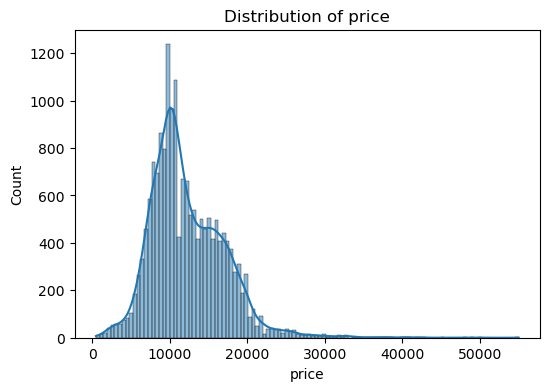

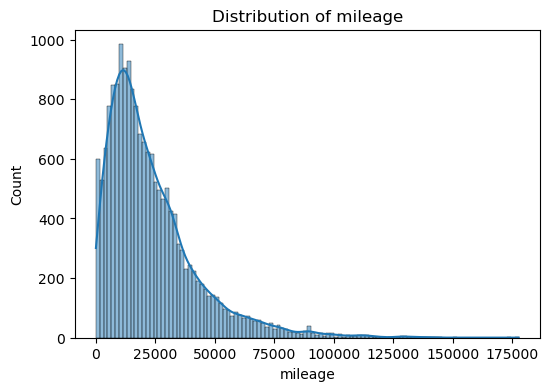

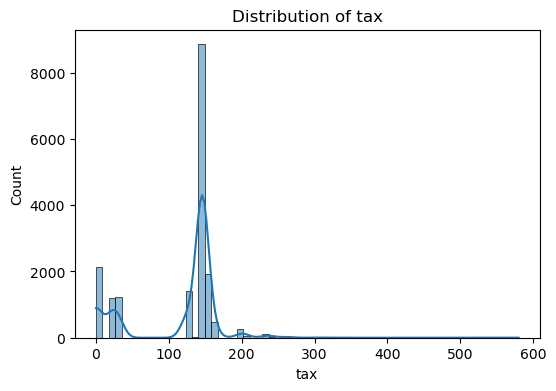

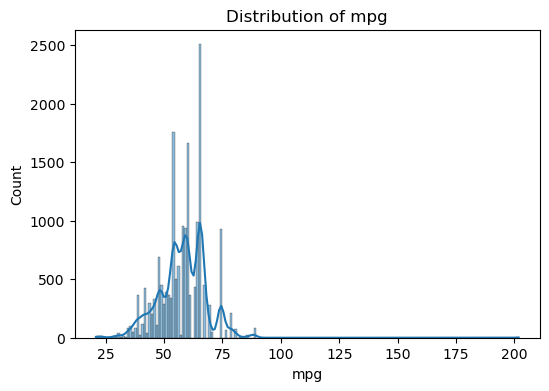

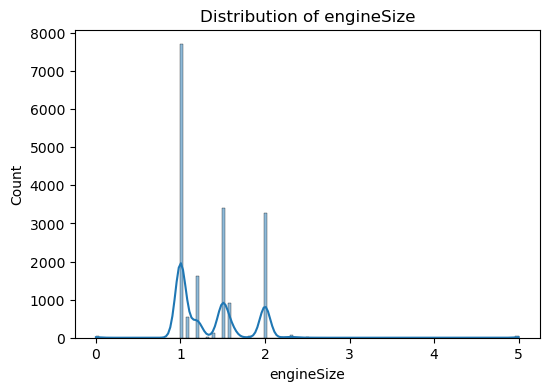

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["price","mileage","tax","mpg","engineSize"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [14]:
df["price"] = np.log1p(df["price"])

In [15]:
df["model"].nunique()

23

In [16]:
df["model"].value_counts()

model
 Fiesta                   6509
 Focus                    4555
 Kuga                     2208
 EcoSport                 1127
 C-MAX                     542
 Ka+                       523
 Mondeo                    512
 B-MAX                     350
 S-MAX                     294
 Grand C-MAX               247
 Galaxy                    227
 Edge                      205
 KA                        197
 Puma                       79
 Tourneo Custom             69
 Mustang                    57
 Grand Tourneo Connect      57
 Tourneo Connect            32
 Fusion                     16
 Streetka                    2
 Ranger                      1
 Escort                      1
 Transit Tourneo             1
Name: count, dtype: int64

In [17]:
df["transmission"].nunique()

3

In [18]:
df["fuelType"].nunique()

5

In [19]:
num_cols = ["mileage","tax","mpg","engineSize"]

for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1

    LOWER_BOUND = Q1-1.5*IQR
    UPPER_BOUND = Q3+1.5*IQR
    outliers = df[(df[col]< LOWER_BOUND) | (df[col] > UPPER_BOUND)]
    print(outliers.shape[0])

864
20
216
190


The dataset was first cleaned for any duplicate entries and missing values. Duplicates were removed, and there were no missing values. A new feature,car_age, was created based on the year column. The correlation and distribution of numerical variables were analyzed, and outliers were detected using the IQR method without any removal of data.

In [20]:
df.shape

(17811, 9)

In [21]:
df.head()

,model,price,transmission,mileage,fuelType,tax,mpg,engineSize,car_age
0,Fiesta,9.392745,Automatic,15944,Petrol,150,57.7,1.0,9
1,Focus,9.546884,Manual,9083,Petrol,150,57.7,1.0,8
2,Focus,9.472782,Manual,12456,Petrol,150,57.7,1.0,9
3,Fiesta,9.770013,Manual,10460,Petrol,145,40.3,1.5,7
4,Fiesta,9.711176,Automatic,1482,Petrol,145,48.7,1.0,7


In [22]:
df = pd.get_dummies(df, columns=["transmission","fuelType","model"], drop_first=True)

In [23]:
X = df.drop("price", axis=1)
y = df["price"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
random_state=42)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_log = lr.predict(X_test)

In [28]:
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)
r2=r2_score(y_test_actual,y_pred_actual)
print("Linear Regression R2:",r2)

Linear Regression R2: 0.8877300050338974


## KNN Regressor

In [29]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()
knn.fit(X_train_scaled,y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [30]:
y_pred_actual = np.expm1(y_pred_knn)
y_test_actual = np.expm1(y_test)
r2=r2_score(y_test_actual,y_pred_actual)
print("KNN R2:",r2)

KNN R2: 0.9345155980396519


## SVM Regressor

In [31]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train_scaled,y_train)
y_pred_svr = svr.predict(X_test_scaled)

In [32]:
y_pred_actual = np.expm1(y_pred_svr)
y_test_actual = np.expm1(y_test)
r2=r2_score(y_test_actual,y_pred_actual)
print("SVR R2:",r2)

SVR R2: 0.9329869682702634


## Random Forest Regressor

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200,max_depth=10,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

In [34]:
y_pred_actual = np.expm1(y_pred_rf)
y_test_actual = np.expm1(y_test)
r2=r2_score(y_test_actual,y_pred_actual)
print("Random Forest R2:",r2)

Random Forest R2: 0.932452144372595


In [36]:
y_train_actual = np.expm1(y_train)
train_r2 = r2_score(y_train_actual, np.expm1(rf.predict(X_train)))
print("Train R2:", train_r2)

Train R2: 0.9420454651448078


Several regression models were trained and compared for the prediction of car prices, including Linear Regression, KNN Regressor, SVR, and Random Forest Regressor.Among these regression models, the KNN Regressor had the best performance, scoring an R² value of about 0.93. SVR and Random Forest Regressor had similar performance scores.Linear Regression had slightly low performance compared to other regression models, scoring an R² value of about 0.88, indicating that the relationship between vehicle features and car prices is not linear. Models that can handle non-linear relationships are better for this problem.